# Train SAE and Interpret Themes

This notebook runs the full **In Your Own Words** pipeline on any text dataset:

1. **Load** — read texts from a CSV file  
2. **Embed** — encode texts with an OpenAI embedding model  
3. **Train SAE** — fit a sparse autoencoder on the embeddings  
4. **Interpret** — use an LLM to label each SAE dimension with a theme  
5. **Save** — write fidelity scores and theme labels to CSV  
6. **Annotate** — classify each response against the high-fidelity themes  
7. **Analyze** — visualize theme distributions across demographic groups  

**Requirements:** Set `OPENAI_API_KEY` in a `.env` file (or as an environment variable).

## Step 0 — Configuration

Edit these variables to point to your dataset and describe your survey question.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nicapotato/womens-ecommerce-clothing-reviews")

print("Path to dataset files:", path)

Path to dataset files: /Users/jennywang/.cache/kagglehub/datasets/nicapotato/womens-ecommerce-clothing-reviews/versions/1


In [ ]:
# ── Data ──────────────────────────────────────────────────────────────────────
DATA_FILE   = f"{path}/Womens Clothing E-Commerce Reviews.csv"
TEXT_COLUMN = "Review Text"

# ── Survey context (used to generate LLM instructions) ────────────────────────
SURVEY_QUESTION = (
    "Write a review of a women's clothing item you purchased."
)

# ── SAE hyperparameters ───────────────────────────────────────────────────────
M = 32   # number of SAE dimensions (themes)
K = 4    # max active dimensions per response

# ── Embedding ─────────────────────────────────────────────────────────────────
EMBEDDING_MODEL = "text-embedding-3-large"  # OpenAI embedding model
EMBEDDING_FILE  = "clothing_review_embeddings.npy"          # cache embeddings here to avoid re-computing

# ── Output ────────────────────────────────────────────────────────────────────
CACHE_NAME      = f"clothing_reviews_{M}_{K}"                        # name for LLM cache
CHECKPOINT_DIR  = f"sae_cache/checkpoints/{CACHE_NAME}"    # where to save SAE weights
OUTPUT_FILE     = f"sae_cache/{CACHE_NAME}_themes.csv"     # where to save final themes

## Step 1 — Setup

In [46]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()
os.environ['OPENAI_KEY_SAE'] = os.getenv('OPENAI_API_KEY', '')

from hypothesaes.quickstart import train_sae
from hypothesaes.interpret_neurons import (
    NeuronInterpreter, InterpretConfig, LLMConfig, SamplingConfig
)

Path("sae_cache").mkdir(exist_ok=True)
print("Setup complete.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setup complete.


## Step 2 — Load data

In [47]:
df = pd.read_csv(DATA_FILE)
df = df.sample(500, random_state=42) # just a subset to showcase process

# Drop rows with missing text
df = df.dropna(subset=[TEXT_COLUMN]).reset_index(drop=True)
texts = df[TEXT_COLUMN].tolist()

print(f"Loaded {len(texts)} responses from '{DATA_FILE}'")
print("\nSample responses:")
for t in texts[:10]:
    print(f"  • {t[:120]}")

Loaded 479 responses from '/Users/jennywang/.cache/kagglehub/datasets/nicapotato/womens-ecommerce-clothing-reviews/versions/1/Womens Clothing E-Commerce Reviews.csv'

Sample responses:
  • I agree with the other reviewer that the color isn't as pink in person and more subtle. my thoughts below on some other 
  • I have many sweaters but i bought this during the sale and it is very soft and comfortable.
  • Beautiful top but runs a whole size small. gave to my daughter who loved!
  • I loved these pants.they are so comfortable. however, after just wearing them twice, the threads of the leaves are frayi
  • I ordered this dress in a petite but it arrived in a regular, the rest fit and in the meantime the petites ran out in my
  • Such a cute shirt! i picked up the white-with-flowers that is not being shown online yet. the straight white looks like 
  • Had to send back for exchange. way too big. i'm very excited to get a smaller size because they are really beautifully m
  • I liked this

## Step 3 — Embed texts

Embeddings are cached to `EMBEDDING_FILE` so re-running this cell is fast.

In [48]:
from openai import OpenAI

def embed_texts(texts, model=EMBEDDING_MODEL, batch_size=100):
    """Embed a list of texts using the OpenAI API, in batches."""
    client = OpenAI()
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        response = client.embeddings.create(input=batch, model=model)
        all_embeddings.extend([item.embedding for item in response.data])
        print(f"  Embedded {min(i + batch_size, len(texts))}/{len(texts)} texts", end="\r")
    print()
    return np.array(all_embeddings, dtype=np.float32)

if Path(EMBEDDING_FILE).exists():
    print(f"Loading cached embeddings from '{EMBEDDING_FILE}'")
    embeddings = np.load(EMBEDDING_FILE)
else:
    print(f"Embedding {len(texts)} texts with '{EMBEDDING_MODEL}'...")
    embeddings = embed_texts(texts)
    np.save(EMBEDDING_FILE, embeddings)
    print(f"Saved embeddings to '{EMBEDDING_FILE}'")

print(f"Embeddings shape: {embeddings.shape}")

Loading cached embeddings from 'embeddings.npy'
Embeddings shape: (479, 3072)


## Step 4 — Train SAE and generate theme interpretations

In [49]:
# Build generic LLM instructions from the survey question
TASK_INSTRUCTIONS = f"""All of the texts are responses to the question:
{SURVEY_QUESTION}
Features should describe a specific aspect of the response. For example:
- "mentions ..."
- "self-describes as ..."
- "discusses ..."
"""

# Train (or load from checkpoint if it already exists)
sae = train_sae(
    embeddings=embeddings,
    M=M,
    K=K,
    checkpoint_dir=CHECKPOINT_DIR,
)
print(f"SAE trained: {M} dimensions, {K} active per response")

  0%|          | 0/100 [00:00<?, ?it/s]

Saved model to sae_cache/checkpoints/clothing_reviews_32_4/SAE_M=32_K=4.pt
SAE trained: 32 dimensions, 4 active per response


In [50]:
import sys
sys.path.insert(0, str(Path("../scripts").resolve()))
from train_sae import generate_interpretations_and_fidelity_scores

results_df = generate_interpretations_and_fidelity_scores(
    M=M,
    texts=texts,
    embeddings=embeddings,
    sae=sae,
    cache_name=CACHE_NAME,
    n_candidate_interpretations=3,
    task_specific_instructions=TASK_INSTRUCTIONS,
)

print("\nSample interpretations:")
for _, row in results_df.head(5).iterrows():
    print(f"  {row['interpretation']}  (F1={row['f1_fidelity_score']:.2f})")

Embeddings shape: (479, 3072)


Computing activations (batchsize=16384):   0%|          | 0/1 [00:00<?, ?it/s]

Activations shape (from 1 SAEs): (479, 32)

Step 2: Interpreting selected neurons


Generating interpretations:   0%|          | 0/96 [00:00<?, ?it/s]


Step 3: Scoring Interpretations
[WARNING] Only found 37 examples with positive activation, using all available
[WARNING] Only found 49 examples with positive activation, using all available
[WARNING] Only found 32 examples with positive activation, using all available
[WARNING] Only found 49 examples with positive activation, using all available
[WARNING] Only found 38 examples with positive activation, using all available
[WARNING] Only found 37 examples with positive activation, using all available
[WARNING] Only found 46 examples with positive activation, using all available
[WARNING] Only found 42 examples with positive activation, using all available
[WARNING] Only found 49 examples with positive activation, using all available
Found 0 cached items; annotating 9387 uncached items


Scoring neuron interpretation fidelity (32 neurons; 3 candidate interps per neuron; 100 examples to score each…


Sample interpretations:
  mentions how the clothing item highlights or affects specific body features (e.g., hips, shoulders, chest, waist)  (F1=0.81)
  mentions jeans or overalls  (F1=0.61)
  mentions a 'top' as the clothing item under review  (F1=0.90)
  mentions that the clothing item runs large or is oversized  (F1=0.81)
  mentions specific body measurements or proportions  (F1=0.67)


In [55]:
results_df

,neuron_idx,source_sae,interpretation,f1_fidelity_score
15,15,"(32, 4)",mentions dresses,0.958333
2,2,"(32, 4)",mentions a 'top' as the clothing item under re...,0.900000
27,27,"(32, 4)",mentions issues with fabric quality or durability,0.884494
19,19,"(32, 4)",mentions sweaters or cardigans,0.868636
14,14,"(32, 4)",mentions pants or jeans,0.864368
18,18,"(32, 4)",mentions height and weight measurements of the...,0.860000
0,0,"(32, 4)",mentions how the clothing item highlights or a...,0.808889
3,3,"(32, 4)",mentions that the clothing item runs large or ...,0.808889
12,12,"(32, 4)",mentions returning or not keeping the item due...,0.800000
13,13,"(32, 4)",mentions shirts,0.768919


## Step 5 — Save theme results

In [56]:
results_df = results_df.sort_values("f1_fidelity_score", ascending=False)
results_df.to_csv(OUTPUT_FILE, index=False)

print(f"Saved {len(results_df)} theme interpretations to '{OUTPUT_FILE}'")
results_df

Saved 32 theme interpretations to 'sae_cache/clothing_reviews_32_4_themes.csv'


,neuron_idx,source_sae,interpretation,f1_fidelity_score
15,15,"(32, 4)",mentions dresses,0.958333
2,2,"(32, 4)",mentions a 'top' as the clothing item under re...,0.900000
27,27,"(32, 4)",mentions issues with fabric quality or durability,0.884494
19,19,"(32, 4)",mentions sweaters or cardigans,0.868636
14,14,"(32, 4)",mentions pants or jeans,0.864368
18,18,"(32, 4)",mentions height and weight measurements of the...,0.860000
0,0,"(32, 4)",mentions how the clothing item highlights or a...,0.808889
3,3,"(32, 4)",mentions that the clothing item runs large or ...,0.808889
12,12,"(32, 4)",mentions returning or not keeping the item due...,0.800000
13,13,"(32, 4)",mentions shirts,0.768919


## Step 6 -- Annotate remaining themes

In [53]:
from hypothesaes.annotate import annotate_texts_with_concepts

# Filter to themes with sufficient fidelity
FIDELITY_THRESHOLD = 0.5
themes = results_df[results_df["f1_fidelity_score"] >= FIDELITY_THRESHOLD]["interpretation"].tolist()
print(f"Annotating {len(themes)} themes with fidelity >= {FIDELITY_THRESHOLD}")

# Classify each response as activating each theme (1) or not (0)
annotations = annotate_texts_with_concepts(
    texts=texts,
    concepts=themes,
    max_words_per_example=128,
    cache_name=CACHE_NAME,
    n_workers=10,
    model="gpt-4o-mini",
)

annotations_df = pd.DataFrame(annotations)
ANNOTATIONS_FILE = f"sae_cache/{CACHE_NAME}_annotations.csv"
annotations_df.to_csv(ANNOTATIONS_FILE, index=False)

print(f"Saved {len(texts)} × {len(themes)} annotation matrix to '{ANNOTATIONS_FILE}'")
annotations_df.head()

Annotating 27 themes with fidelity >= 0.5
Found 0 cached items; annotating 12933 uncached items


Annotating:   0%|          | 0/12933 [00:00<?, ?it/s]

Saved 479 × 27 annotation matrix to 'sae_cache/clothing_reviews_32_4_annotations.csv'


,mentions dresses,mentions a 'top' as the clothing item under review,mentions issues with fabric quality or durability,mentions sweaters or cardigans,mentions pants or jeans,mentions height and weight measurements of the reviewer,"mentions how the clothing item highlights or affects specific body features (e.g., hips, shoulders, chest, waist)",mentions that the clothing item runs large or is oversized,mentions returning or not keeping the item due to fit issues,mentions shirts,...,mentions a jacket,mentions the word flattering or discusses flattering fit/shape,mentions jeans or overalls,mentions returning or returning the item,mentions dissatisfaction with color or pattern accuracy compared to expectations,mentions a skirt,mentions specific body measurements or weight,mentions softness or comfort in a positive context,"mentions specific sizing details (e.g., size ordered, fit description, body measurements)",mentions occasions or events where the clothing will be worn
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,1,1,0
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,1,0,1,0,0,0,1,0,...,0,0,0,1,1,0,0,1,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


## Step 7 — Analyze themes by categorical var

Use the stacked bar chart below to see which themes are more or less common across any categorical variable in your dataset (e.g. gender, race, age group, region).

Set `CATEGORY_COLUMN` to the name of the column you want to group by.

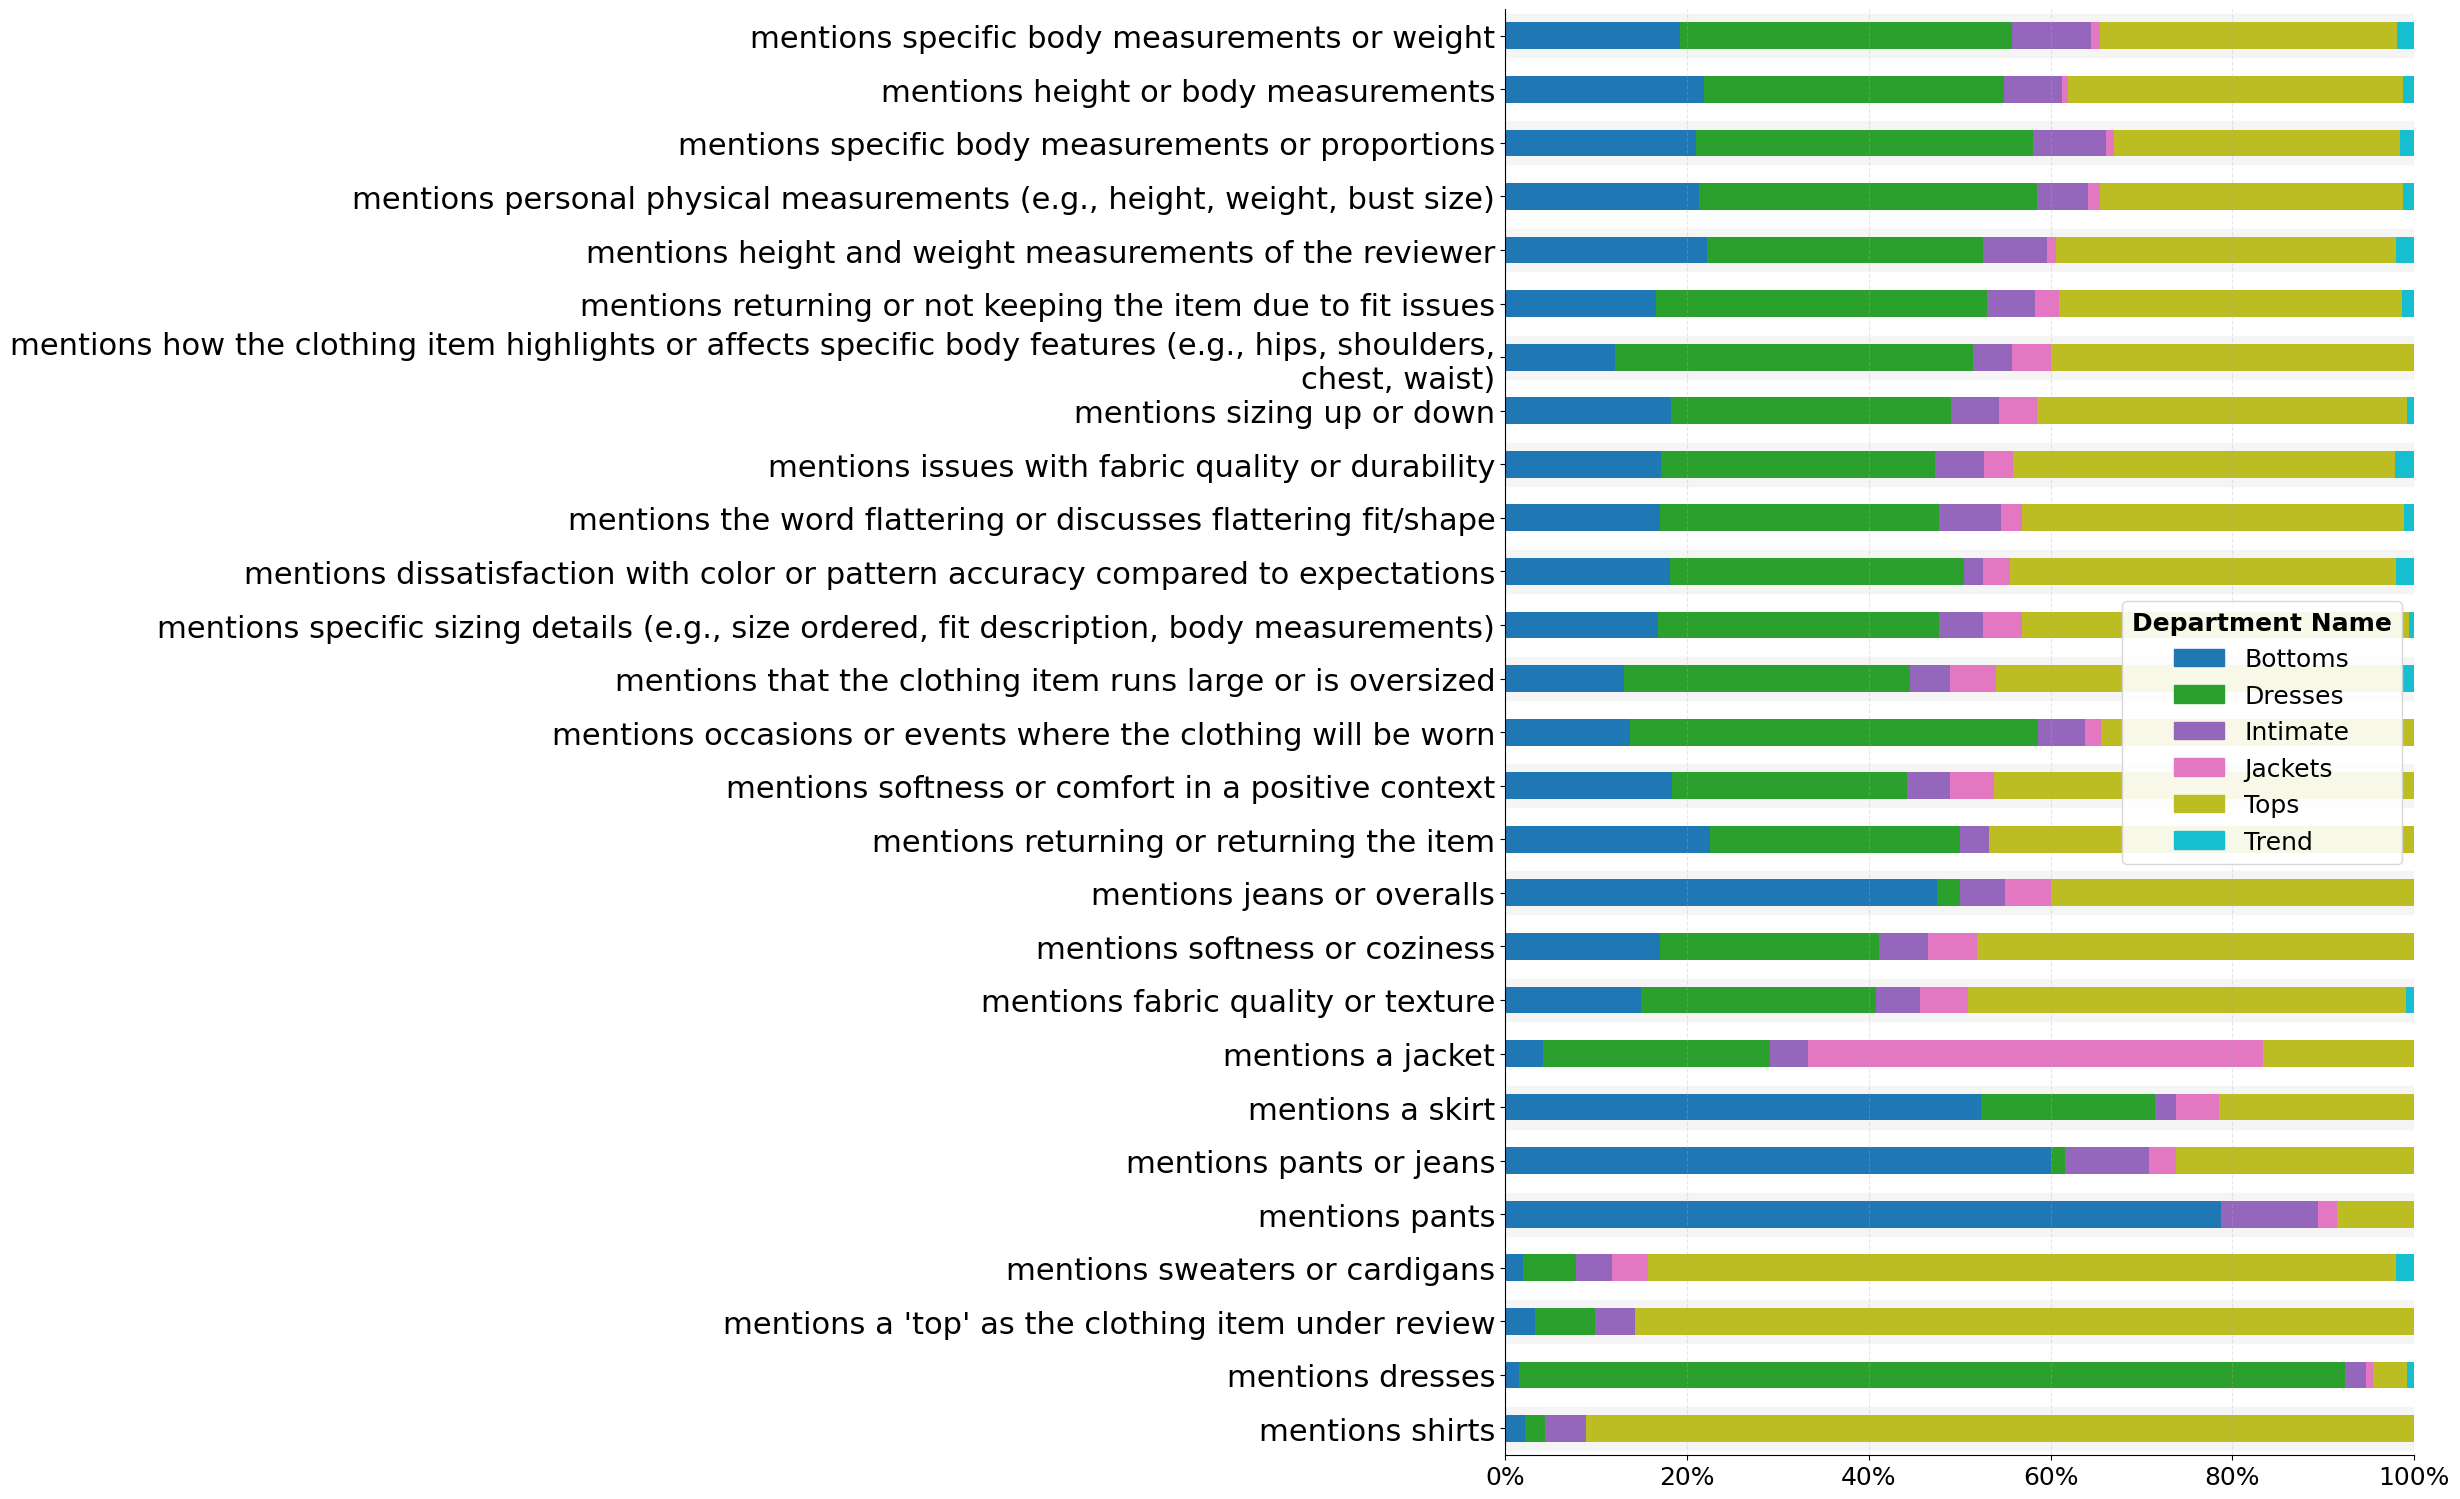

In [59]:
from quickstart_figures import calculate_proportions, themes_barchart

# Set the categorical column you want to analyze
# Good options for this dataset:
#   "Department Name"  — Tops, Dresses, Bottoms, Intimate, Jackets, Trend
#   "Rating"           — 1–5 stars (what do happy vs. unhappy reviewers say?)
#   "Division Name"    — General, General Petite, Initmates
CATEGORY_COLUMN = "Department Name"

# Compute the proportion of each theme activated by each group
proportions = calculate_proportions(annotations_df, df, CATEGORY_COLUMN)

# Plot a stacked bar chart — themes sorted by how group-specific they are
fig = themes_barchart(
    proportions,
    category_column=CATEGORY_COLUMN,
    sort_by="min_max_any_group",  # 'majority' or 'r2' also supported
)

### Multiple categories

To compare themes across several demographic variables at once, loop over a list of columns.


── Department Name ──


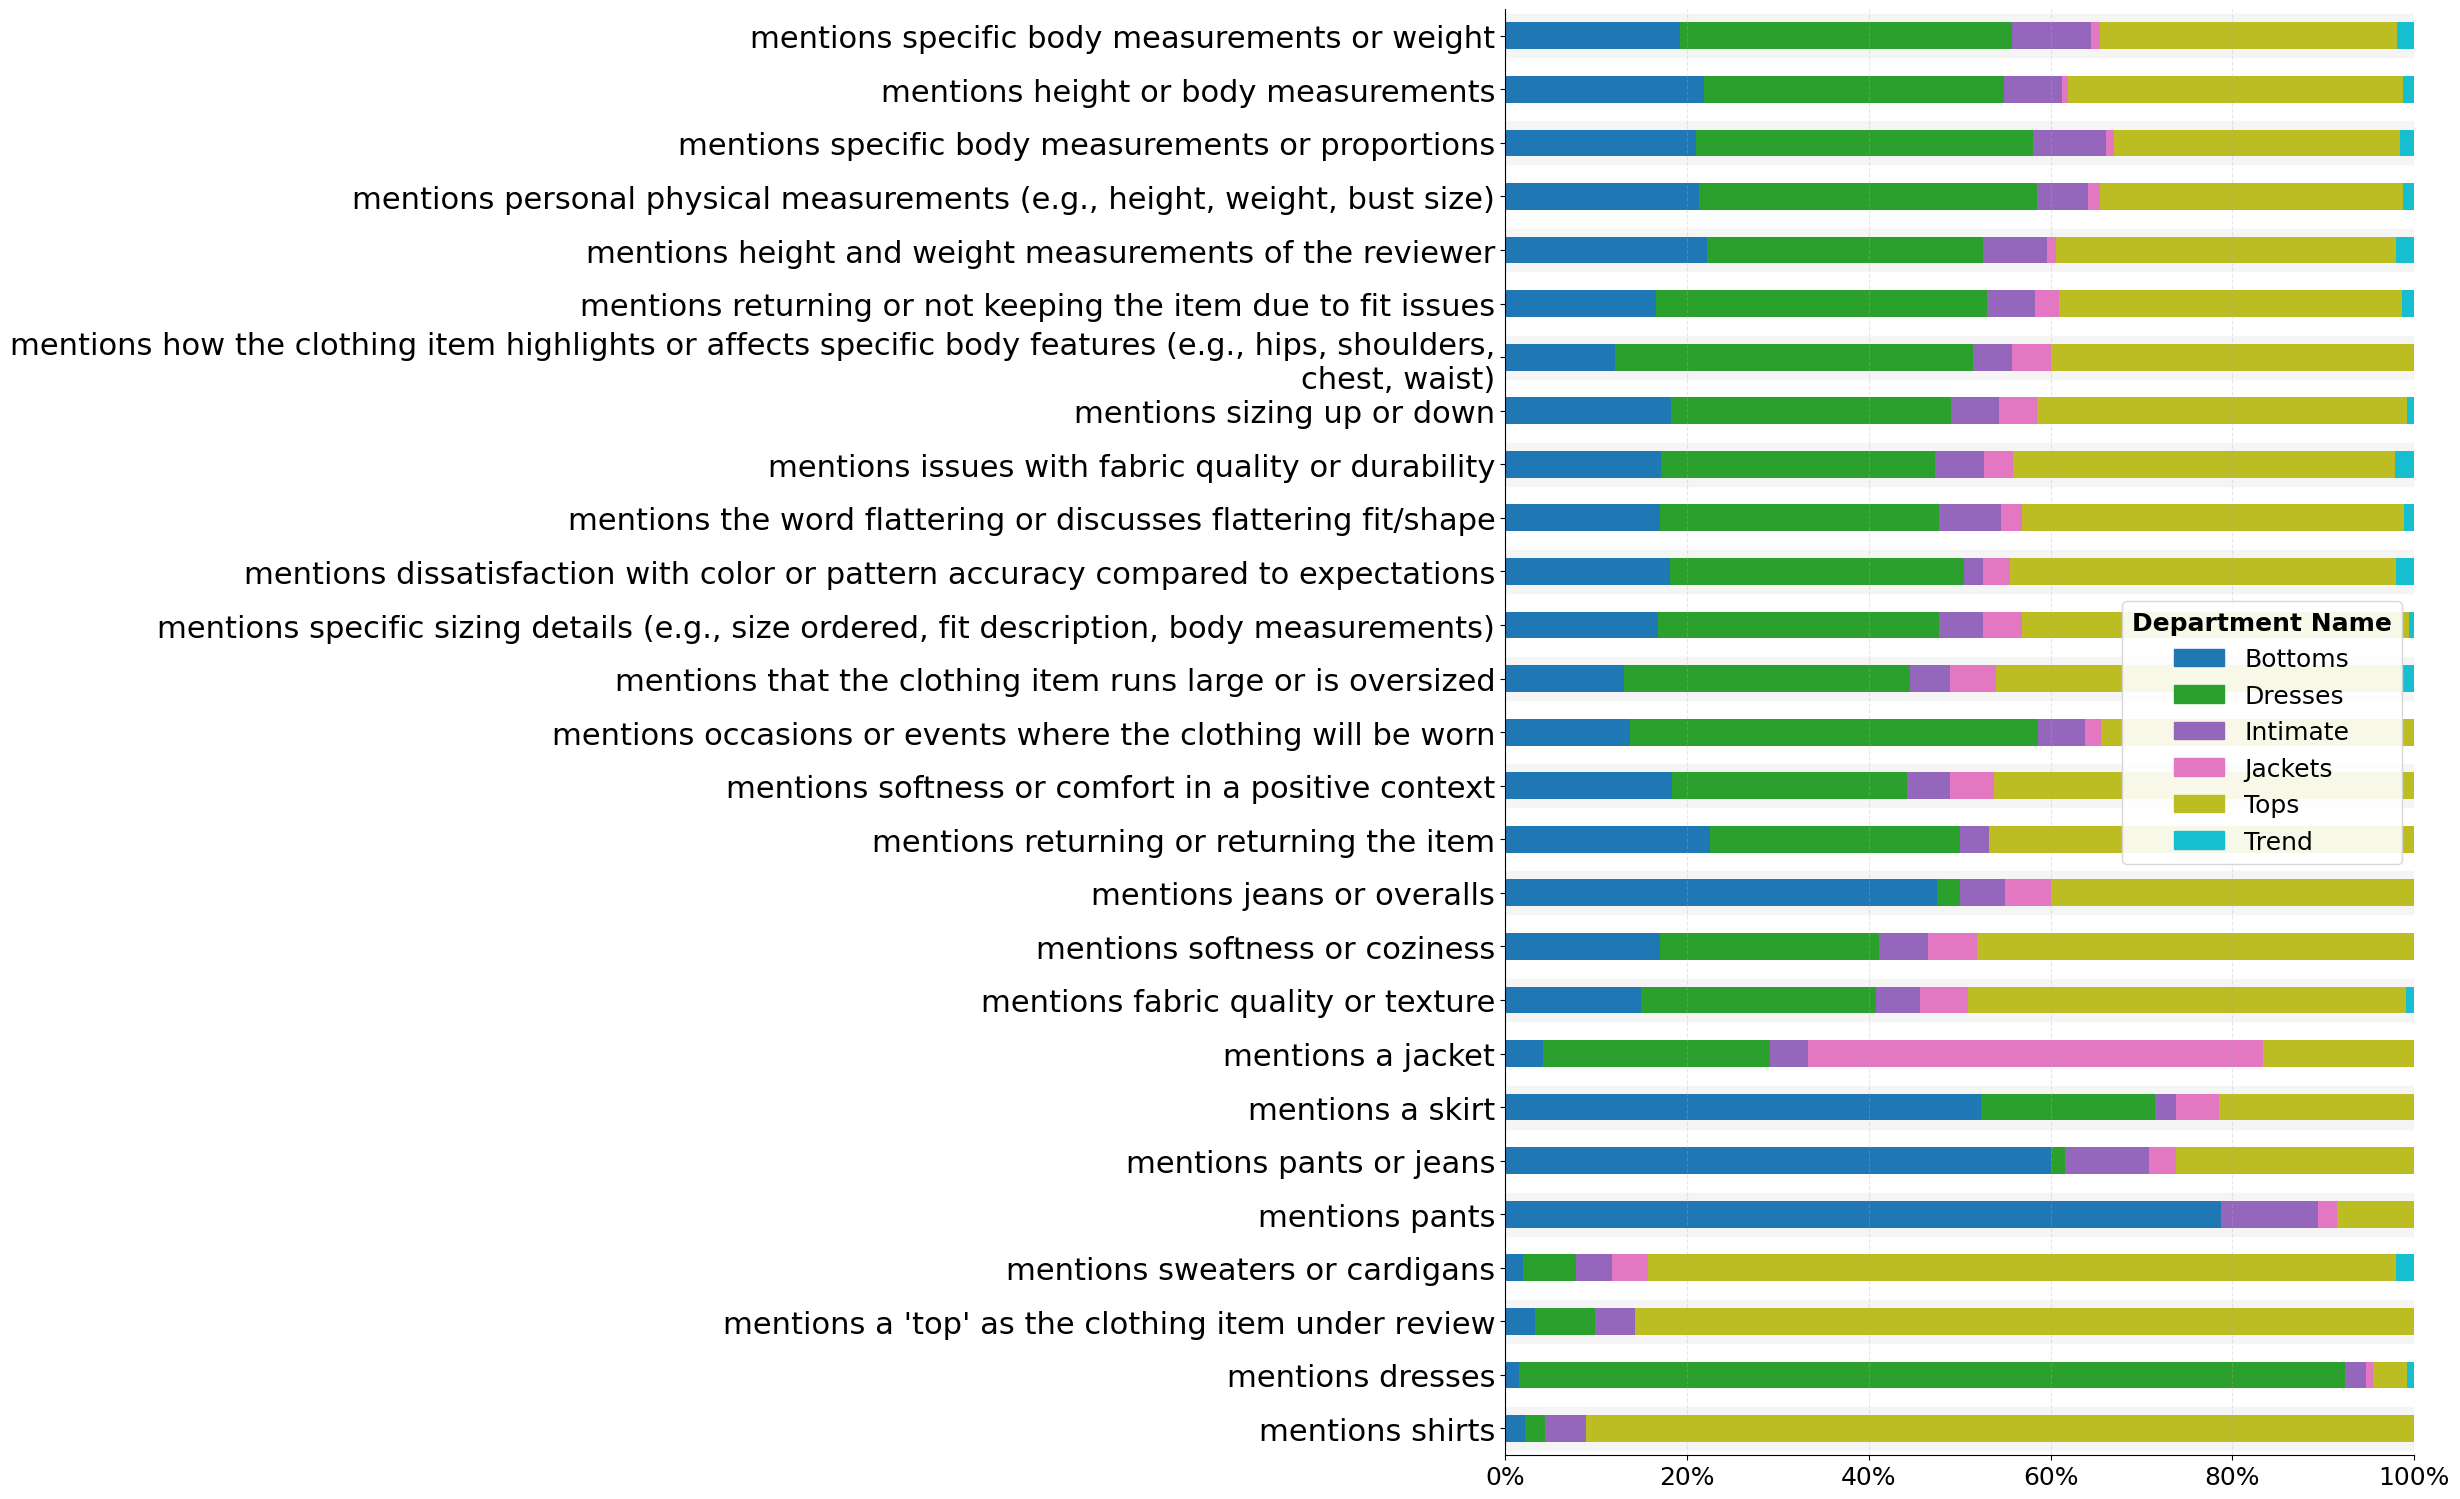


── Rating ──


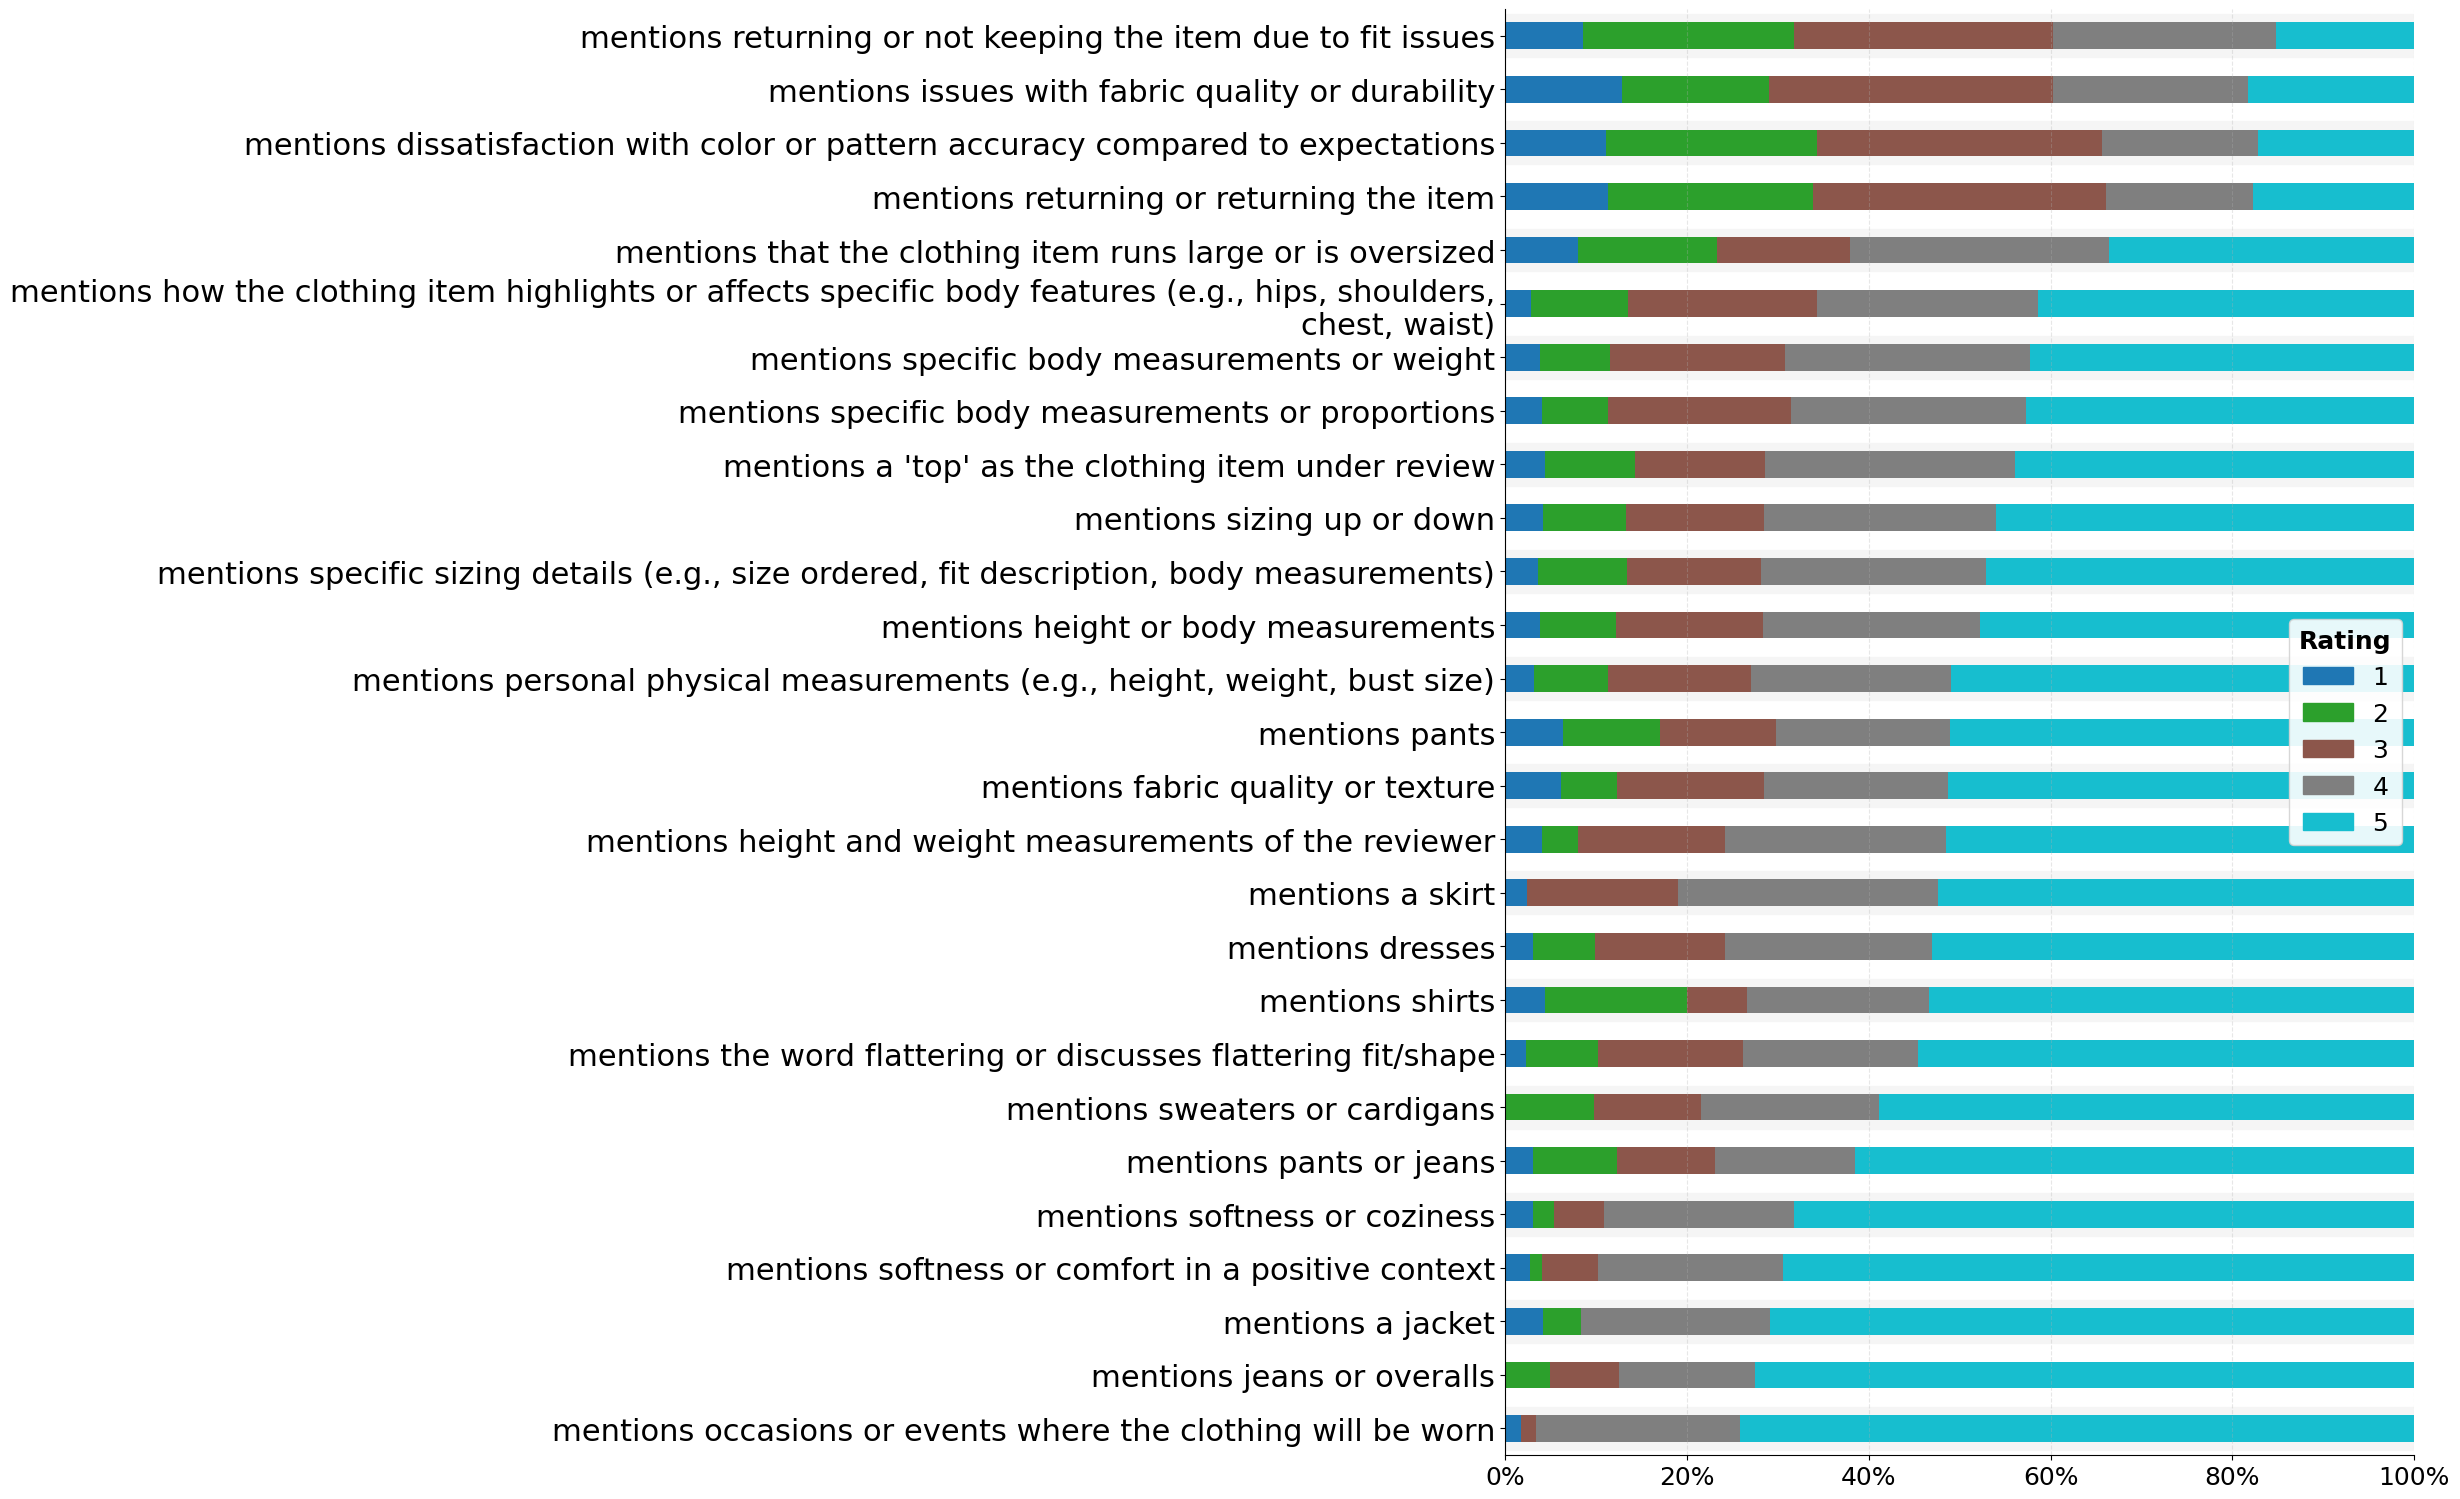


── Division Name ──


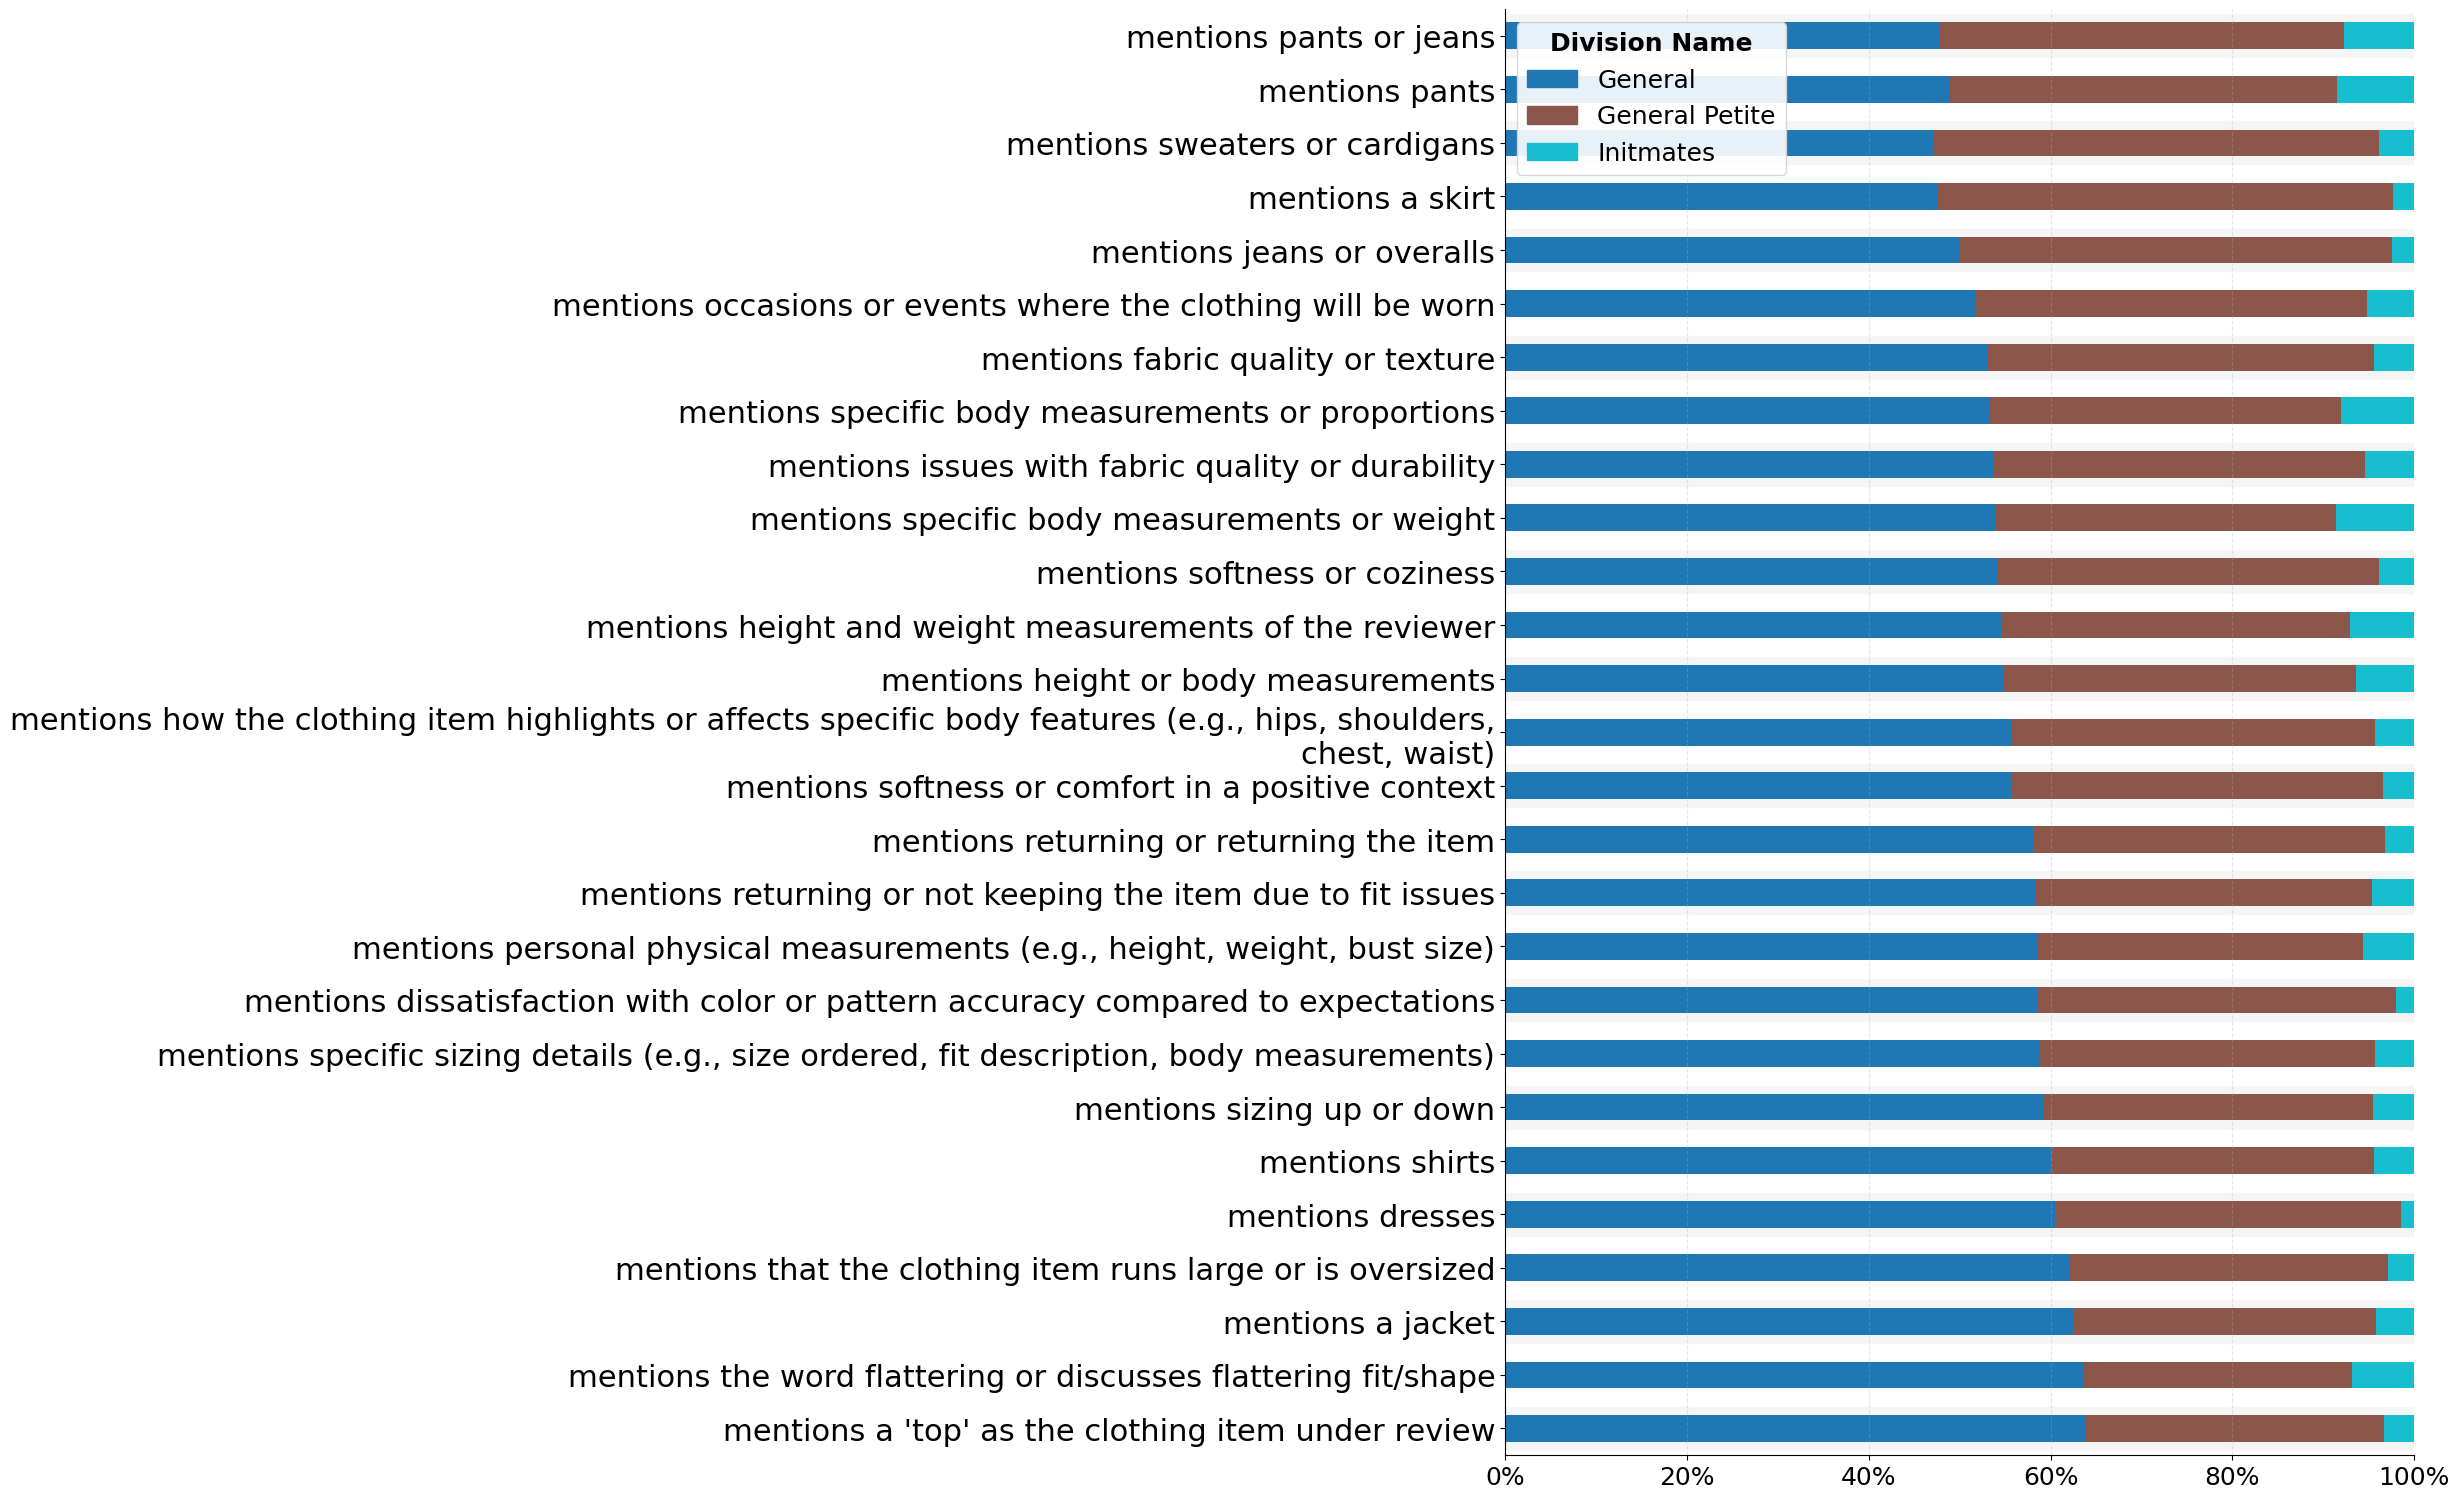

In [60]:
CATEGORY_COLUMNS = ["Department Name", "Rating", "Division Name"]

for col in CATEGORY_COLUMNS:
    print(f"\n── {col} ──")
    proportions = calculate_proportions(annotations_df, df, col)
    themes_barchart(proportions, category_column=col, sort_by="min_max_any_group")